**Install Required Packages**

In [1]:
!pip install google-cloud-bigquery google-cloud-storage google-auth


**Import libraries and initialize client instances**


In [2]:
import os
import asyncio
import google.auth

os.environ['GOOGLE_CLOUD_PROJECT']

GOOGLE_CLOUD_PROJECT = "us-gcp-ame-con-e5556-npd-1"
GOOGLE_CLOUD_LOCATION = "us-central1"
MODEL_NAME = "gemini-2.5-flash"

os.environ['GOOGLE_CLOUD_PROJECT'] = GOOGLE_CLOUD_PROJECT
os.environ['GOOGLE_CLOUD_LOCATION'] = GOOGLE_CLOUD_LOCATION
os.environ['MODEL_NAME'] = MODEL_NAME

google.auth.default()

(<google.auth.compute_engine.credentials.Credentials at 0x7b3797320d70>,
 'us-gcp-ame-con-e5556-npd-1')

In [3]:
os.getenv("GOOGLE_CLOUD_PROJECT")
os.getenv("GOOGLE_CLOUD_LOCATION")

'us-central1'

In [11]:
from google.cloud import bigquery
from google.cloud import storage

# Initialize BigQuery and Storage clients
bigquery_client = bigquery.Client()
storage_client = storage.Client()

# --- Configuration for your data load ---
# Replace with your project ID, dataset ID, table ID, and GCS bucket details
project_id = "us-gcp-ame-con-e5556-npd-1"
location = "us-central1"
dataset_id = "emergency_response"
raw_table_id = "flight_transponder_data"

streaming_project_id = "paul-leroy"
streaming_topic_id = "flight-transponder"
streaming_subscription_id = "flight_transponder_sub"

**Create Table to store the Flight Transponder data from PubSub**



In [5]:
schema = [
bigquery.SchemaField("MT", "STRING", mode="NULLABLE", description="SEL ID AIR STA CLK MSG info http://woodair.net/sbs/Article/Barebones42_Socket_Data.htm"),
bigquery.SchemaField("TT", "INT64", mode="NULLABLE", description="1 - 8"),
bigquery.SchemaField("SID", "STRING", mode="NULLABLE", description="Database Session record number"),
bigquery.SchemaField("AID", "STRING", mode="NULLABLE", description="Database Aircraft record number"),
bigquery.SchemaField("Hex", "STRING", mode="NULLABLE", description="Aircraft Mode S hexadecimal code https://opensky-network.org/datasets/metadata/"),
bigquery.SchemaField("FID", "STRING", mode="NULLABLE", description="Database Flight record number"),
bigquery.SchemaField("DMG", "DATE", mode="NULLABLE", description="Date message generated"),
bigquery.SchemaField("TMG", "TIME", mode="NULLABLE", description="Time message generated"),
bigquery.SchemaField("DML", "DATE", mode="NULLABLE", description="Date message logged"),
bigquery.SchemaField("TML", "TIME", mode="NULLABLE", description="Time message logged"),
bigquery.SchemaField("CS", "STRING", mode="NULLABLE", description="Callsign (flight number or registration)"),
bigquery.SchemaField("Alt", "INT64", mode="NULLABLE", description="Mode C altitude (Flight Level)"),
bigquery.SchemaField("GS", "INT64", mode="NULLABLE", description="Ground Speed"),
bigquery.SchemaField("Trk", "INT64", mode="NULLABLE", description="Track"),
bigquery.SchemaField("Lat", "FLOAT64", mode="NULLABLE", description="Latitude (N/E positive, S/W negative)"),
bigquery.SchemaField("Lng", "FLOAT64", mode="NULLABLE", description="Longitude (N/E positive, S/W negative)"),
bigquery.SchemaField("VR", "INT64", mode="NULLABLE", description="Vertical Rate"),
bigquery.SchemaField("Sq", "STRING", mode="NULLABLE", description="Assigned Mode A squawk code"),
bigquery.SchemaField("Alrt", "INT64", mode="NULLABLE", description="Flag to indicate squawk has changed"),
bigquery.SchemaField("Emer", "INT64", mode="NULLABLE", description="Flag to indicate emergency code has been set"),
bigquery.SchemaField("SPI", "INT64", mode="NULLABLE", description="Flag to indicate transponder Ident has been activated"),
bigquery.SchemaField("Gnd", "INT64", mode="NULLABLE", description="Flag to indicate ground squat switch is active"),
]

**Create Table**

In [12]:
table_ref = bigquery_client.dataset(dataset_id).table(raw_table_id)
table = bigquery.Table(table_ref, schema=schema)
table = bigquery_client.create_table(table)
print(f"Table {raw_table_id} created successfully.")


Table flight_transponder_data created successfully.


**Create a Subscription to received streaming data**

In [10]:
from google.cloud import pubsub_v1

publisher = pubsub_v1.PublisherClient()
subscriber = pubsub_v1.SubscriberClient()

topic_path = publisher.topic_path(streaming_project_id, streaming_topic_id)
subscription_path = subscriber.subscription_path(project_id, streaming_subscription_id)

# Create the subscription
try:
    subscription = subscriber.create_subscription(
        name=subscription_path, topic=topic_path
    )
    print(f"Subscription {streaming_subscription_id} created successfully.")
except Exception as e:
    print(f"Error creating subscription: {e}")


Subscription flight_transponder_sub created successfully.


In [20]:
import time
import pandas as pd
import datetime


table_ref = bigquery_client.dataset(dataset_id).table(raw_table_id)


def callback(message):
    try:
        # Decode message data and parse CSV
        data = message.data.decode('utf-8')
        # print(f"Received message: {data}")
        # Strip potential carriage return or newline characters from the end of the data
        data = data.strip()
        values = data.split(',')

        # Create a dictionary matching the schema fields
        row_dict = {
            "MT": values[0].strip(),
            "TT": int(values[1].strip()) if values[1].strip() else None,
            "SID": values[2].strip(),
            "AID": values[3].strip(),
            "Hex": values[4].strip(),
            "FID": values[5].strip(),
            "DMG": datetime.datetime.strptime(values[6].strip(), '%Y/%m/%d').date().strftime('%Y-%m-%d') if values[6].strip() else None,
            "TMG": datetime.datetime.strptime(values[7].strip(), '%H:%M:%S.%f').time().strftime('%H:%M:%S.%f') if values[7].strip() else None,
            "DML": datetime.datetime.strptime(values[8].strip(), '%Y/%m/%d').date().strftime('%Y-%m-%d') if values[8].strip() else None,
            "TML": datetime.datetime.strptime(values[9].strip(), '%H:%M:%S.%f').time().strftime('%H:%M:%S.%f') if values[9].strip() else None,
            "CS": values[10].strip(),
            "Alt": int(values[11].strip()) if values[11].strip() else None,
            "GS": int(values[12].strip()) if values[12].strip() else None,
            "Trk": int(values[13].strip()) if values[13].strip() else None,
            "Lat": float(values[14].strip()) if values[14].strip() else None,
            "Lng": float(values[15].strip()) if values[15].strip() else None,
            "VR": int(values[16].strip()) if values[16].strip() else None,
            "Sq": values[17].strip(),
            "Alrt": int(values[18].strip()) if values[18].strip() else None,
            "Emer": int(values[19].strip()) if values[19].strip() else None,
            "SPI": int(values[20].strip()) if values[20].strip() else None,
            "Gnd": int(values[21].strip()) if values[21].strip() else None,
        }

        # Insert row into BigQuery
        errors = bigquery_client.insert_rows_json(table_ref, [row_dict])
        if errors:
            print(f"Errors inserting row: {errors}")
        # else:
            # print("Row inserted successfully.")

        message.ack()
    except Exception as e:
        print(f"Error processing message: {e}")
        message.nack()

# Subscribe to the topic
streaming_pull_future = subscriber.subscribe(subscription_path, callback=callback)

print(f"Listening for messages on {subscription_path} for 3 minutes...")

# Run for 5 sec
try:
    time.sleep(60)  # 5 sec
finally:
    streaming_pull_future.cancel()
    streaming_pull_future.result()  # Wait for the future to be cancelled
    print("Stopped listening for messages.")

Listening for messages on projects/us-gcp-ame-con-e5556-npd-1/subscriptions/flight_transponder_sub for 3 minutes...
Stopped listening for messages.


In [21]:
query = f"SELECT COUNT(*) FROM `{project_id}.{dataset_id}.{raw_table_id}`"
query_job = bigquery_client.query(query)
results = query_job.result()

for row in results:
    print(f"Number of records: {row[0]}")

Number of records: 19317


In [22]:
query = f"SELECT ST_GEOGPOINT(Lng,Lat) as Location FROM `{project_id}.{dataset_id}.{raw_table_id}` where Lat is not null AND Lng is not null"
query_job = bigquery_client.query(query)
results = query_job.result().to_dataframe()

results.head()

,Location
0,POINT(-0.711291 51.590057)
1,POINT(-1.592102 51.461311)
2,POINT(-1.37886 50.950633)
3,POINT(-0.427205 51.336823)
4,POINT(-1.058731 51.496691)


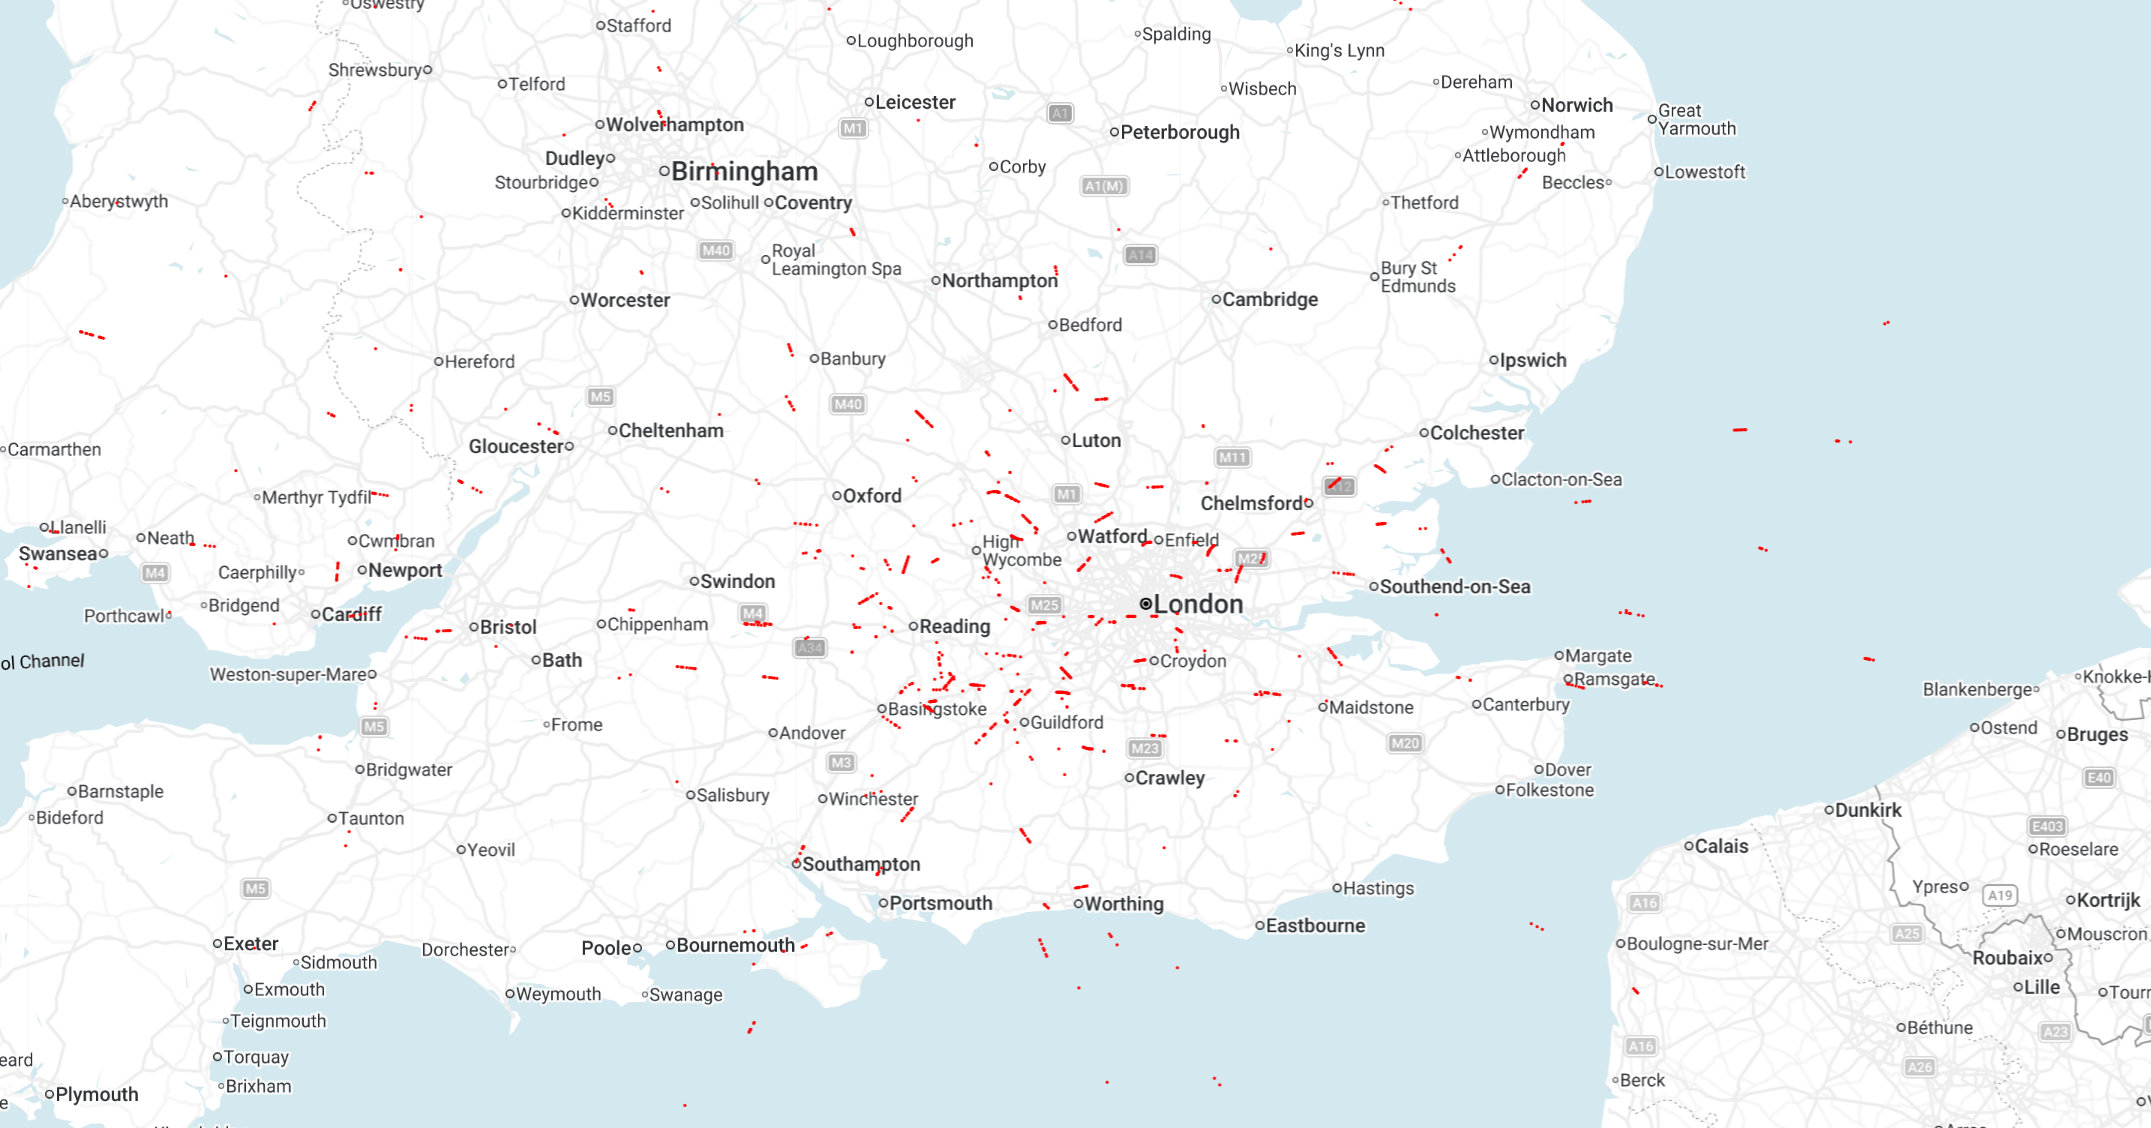